# TSA workforce: is the agency finding it easy or hard to recruit and keep people?

**The question.** In late September 2026 TSA confirmed it was removing the chairs from travel-document-checker
podiums nationwide. A reasonable follow-up: is TSA's workforce in good enough shape that this is one more
irritation, or is the agency already struggling to hire and hold onto officers? Using federal personnel
records we ask:

1. **Is TSA hiring** frontline officers at a normal pace, compared with its own history?
2. **Is that workforce shrinking**, and by how much?
3. **How much passenger volume is there per officer?** TSA does not publish checkpoint wait times, but it publishes how many passengers it screens each day.
4. **Who is leaving**: are new hires leaving quickly, or is the loss among officers who have been there for years?

**Who this covers.** The frontline screening workforce: rank-and-file **Transportation Security Officers** (pay plan `SV`, job series `1802`,
*Compliance Inspection and Support*), **excluding lead officers, supervisors and managers**. Leads are left out because they lead other officers,
and no source says whether the standing rule covers them. Rank-and-file officers are who
stands at checkpoints, so this is the group a standing requirement would most plausibly reach. The records have no job title,
airport, or checkpoint position (those fields are redacted for TSA), so **travel document checkers cannot be picked out** —
they sit in this same group, and officers rotate between document checking, X-ray and bag screening anyway.

**What this can and cannot answer.** These records show who was hired, who left, and who was on the payroll.
They contain **no applicant data** — no applications received, offers declined, or time-to-fill — so they
cannot say whether recruiting is *hard*. They can say whether hiring *happened*, and who left. The data ends before the chair policy (reported September 29, 2026), so it cannot show any
effect of that policy.

**The data.** OPM/EHRI personnel records, mirrored monthly in the HuggingFace dataset
`impactproject/opm-ehri-data`; the file list is built from OPM's own API (`src/build_file_map.py`).
TSA = agency code `HSBC`. Frontline officers = pay plan `SV`, job series `1802`, supervisory status "all other positions" (not a lead, supervisor or manager).

In [1]:
import sys; sys.path.insert(0, "src")
import textwrap
from pathlib import Path
import tsa
import pandas as pd, matplotlib.pyplot as plt, matplotlib.ticker as mtick, matplotlib.dates as mdates
from IPython.display import display, Markdown
pd.set_option("display.max_columns", 30)

def show(df, pct=(), index=False, na_rep="—"):
    """Tidy HTML table: thousands separators, whole numbers without '.0', % where asked."""
    fmt = {}
    for c in df.columns:
        col = df[c]
        if c in pct:
            fmt[c] = lambda v: "" if pd.isna(v) else f"{v:,.1f}%"
        elif pd.api.types.is_numeric_dtype(col):
            s = col.dropna()
            whole = len(s) > 0 and bool((s == s.round()).all())
            fmt[c] = (lambda v: "" if pd.isna(v) else f"{int(round(v)):,}") if whole \
                     else (lambda v: "" if pd.isna(v) else f"{v:,.1f}")
    sty = df.style.format(fmt, na_rep=na_rep)
    return sty if index else sty.hide(axis="index")

def ym_label(ym): return pd.to_datetime(str(ym), format="%Y%m").strftime("%b %Y")
occ_names = pd.read_csv("data/occ_series_names.csv", dtype=str).set_index("code")["name"].to_dict()

C_TSA, C_MUTED = "#2a78d6", "#c0392b"
SPAN = "#fdd9a0"
plt.rcParams.update({
    "figure.dpi": 120, "savefig.bbox": "tight", "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#bbbbbb",
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlepad": 10,
    "axes.labelcolor": "#444", "axes.labelsize": 10, "xtick.color": "#444", "ytick.color": "#444",
    "axes.grid": True, "axes.axisbelow": True, "grid.color": "#dddddd", "grid.linewidth": 0.7,
    "legend.frameon": False,
})
def comma_y(ax): ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))
def date_x(ax):
    loc = mdates.AutoDateLocator(); ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))

con = tsa.con()
def q(sql): return con.execute(sql).df()
def scalar(sql): return con.execute(sql).fetchone()[0]
ACC, SEP, EMP = tsa.ACC, tsa.SEP, tsa.EMP

OFFICER = tsa.FRONTLINE        # frontline screening officers (see the scope table below)
ALL_1802 = tsa.ALL_1802
LATEST = tsa.LATEST_MONTH
YEARS_PARTIAL = int(LATEST[4:])           # 7 months of 2026 so far
FIG = Path("figures"); FIG.mkdir(exist_ok=True)
FRONT_N = None     # set in the group table below; the chart footers print it

def footer(fig, extra="", y=0.0):
    # define the population and point to the repo, under the plot, so each saved image stands alone
    pop = (f"Population: rank-and-file TSA Transportation Security Officers (pay plan SV, job series 1802), excluding lead officers, "
           f"supervisors and managers; {FRONT_N:,} people in {ym_label(LATEST)}.")
    src = f"Source: OPM/EHRI personnel records (impactproject/opm-ehri-data), data through {ym_label(LATEST)}. Code and data: {tsa.REPO_URL}"
    txt = chr(10).join(textwrap.wrap(pop + (" " + extra if extra else ""), 118) + textwrap.wrap(src, 118))
    fig.text(0.01, y, txt, ha="left", va="top", fontsize=7.6, color="#555555", linespacing=1.45)
def save(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=200, bbox_inches="tight")

display(Markdown(f"**As of {tsa.ASOF}. Latest month published by OPM: {ym_label(LATEST)}.**"))

**As of 2026-10-01. Latest month published by OPM: Jul 2026.**

## Who is in the group

July 2026 TSA headcount, split by the groups used in this notebook.

In [2]:
sc = q(f"""SELECT CASE WHEN {tsa.FRONTLINE} THEN '1. Frontline officers: rank-and-file (THE GROUP)'
                  WHEN {ALL_1802} AND supervisory_status = 'LEADER' THEN '2. Lead officers in the same series (not in the group)'
                  WHEN {ALL_1802} THEN '3. Supervisors and managers in the same series (not in the group)'
                  ELSE '4. Everyone else at TSA (other jobs, headquarters, IT, etc.; not in the group)' END AS grp,
               SUM(count) AS n FROM '{EMP}' WHERE snapshot_ym = '{tsa.LATEST_MONTH}' GROUP BY 1 ORDER BY 1""")
sc["share_%"] = 100 * sc.n / sc.n.sum()
display(show(sc.rename(columns={"grp": "Group (July 2026)", "n": "People", "share_%": "Share of TSA"}), pct=["Share of TSA"]))
front_n = int(sc[sc.grp.str.startswith("1.")].n.sum())
FRONT_N = front_n
LEAD_N = int(sc[sc.grp.str.startswith("2.")].n.sum())
print(f"Frontline officers: {front_n:,} of {int(sc.n.sum()):,} TSA employees ({100*front_n/sc.n.sum():.0f}%). By pay band: "
      + ", ".join(f"{r.grade} {int(r.n):,}" for r in q(f"SELECT grade, SUM(count) n FROM '{EMP}' WHERE snapshot_ym='{tsa.LATEST_MONTH}' AND {tsa.FRONTLINE} GROUP BY 1 ORDER BY 1").itertuples())
      + f"; part-time {100*scalar(f"SELECT SUM(CASE WHEN work_schedule ILIKE 'PART%' THEN count END)/SUM(count) FROM '{EMP}' WHERE snapshot_ym='{tsa.LATEST_MONTH}' AND {tsa.FRONTLINE}"):.0f}%.")

Group (July 2026),People,Share of TSA
1. Frontline officers: rank-and-file (THE GROUP),"36,231",60.8%
2. Lead officers in the same series (not in the group),"5,902",9.9%
3. Supervisors and managers in the same series (not in the group),"4,912",8.2%
"4. Everyone else at TSA (other jobs, headquarters, IT, etc.; not in the group)","12,566",21.1%


Frontline officers: 36,231 of 59,611 TSA employees (61%). By pay band: D 1,533, E 4,959, F 29,377, G 362; part-time 17%.


## At a glance

**Top: headcount.** How many frontline officers TSA has had on the payroll each month. **Middle: hires and departures.** New officers added each month,
against officers who left; where the lines cross, the workforce stops growing. **Bottom: passengers per officer.** Passengers TSA screens per day, divided by the officers on
the payroll: a rough workload index, not wait time (§3). All three start in the same month: January 2019, when the passenger counts TSA publishes begin. (The personnel data go back to 2018 and are used in the tables below.)

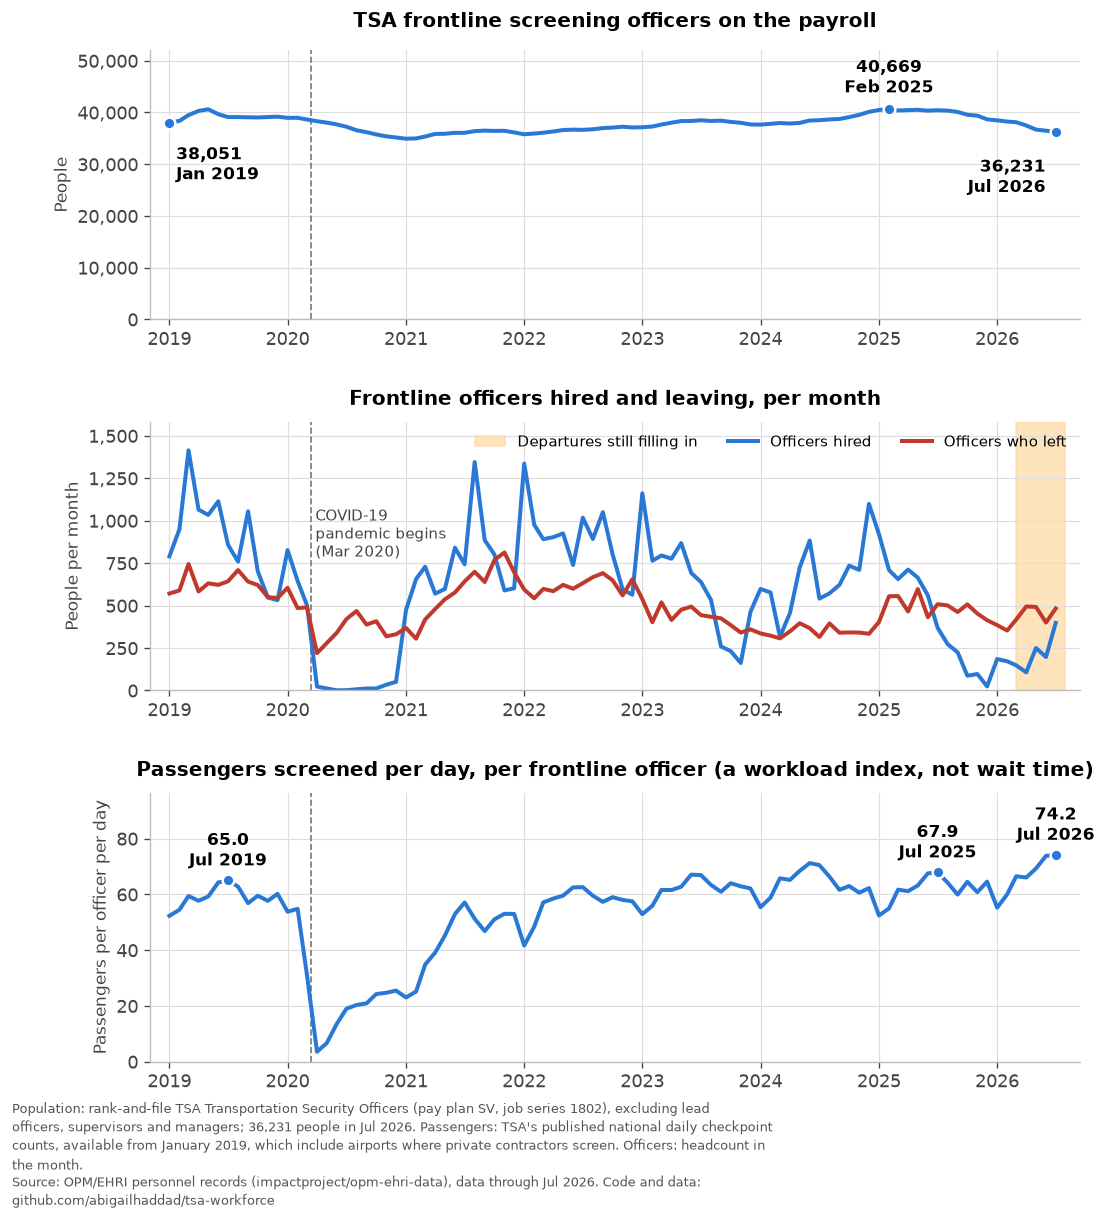

In [3]:
START = pd.read_csv(tsa.PAX, parse_dates=["date"]).date.min().strftime("%Y%m")      # the latest start of the three series: when TSA's published passenger counts begin
hcf = q(f"SELECT snapshot_ym, SUM(count) AS n FROM '{EMP}' WHERE {OFFICER} AND snapshot_ym >= '{START}' GROUP BY 1 ORDER BY 1")
hcf["date"] = pd.to_datetime(hcf.snapshot_ym, format="%Y%m")
pk_ = hcf.loc[hcf.n.idxmax()]; pk_date = pd.to_datetime(pk_.snapshot_ym, format="%Y%m")
fa = q(f"SELECT event_ym, SUM(count) hires FROM '{ACC}' WHERE {OFFICER} AND event_ym >= '{START}' GROUP BY 1")
fs = q(f"SELECT event_ym, SUM(count) seps FROM '{SEP}' WHERE {OFFICER} AND event_ym >= '{START}' GROUP BY 1")
fl = fa.merge(fs, on="event_ym").sort_values("event_ym"); fl = fl[fl.event_ym >= hcf.snapshot_ym.min()]; fl["date"] = pd.to_datetime(fl.event_ym, format="%Y%m")
# workload: passengers per officer per day (TSA's published national daily counts; officers = frontline headcount in the month)
pax = pd.read_csv(tsa.PAX, parse_dates=["date"]); pax["ym"] = pax.date.dt.strftime("%Y%m")
pm = pax.groupby("ym").agg(total=("passengers", "sum"), days=("passengers", "size")); pm["per_day"] = pm.total / pm.days
hcm = hcf.set_index("snapshot_ym").n.rename("officers").to_frame()
wl = pm.join(hcm, how="inner"); wl["per_officer"] = wl.per_day / wl.officers       # only months with both
wl["date"] = pd.to_datetime(wl.index, format="%Y%m")
last_m = wl.index.max(); prev_m = str(int(last_m[:4]) - 1) + last_m[4:]; base_m = wl.index.min()[:4] + last_m[4:]   # same month a year earlier / in the first year of passenger data

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10.6), sharex=True, gridspec_kw={"hspace": 0.38})
ax1.plot(hcf.date, hcf.n, lw=2.4, color=C_TSA)
for x_, y_ in ((hcf.date.iloc[-1], hcf.n.iloc[-1]), (pk_date, pk_.n), (hcf.date.iloc[0], hcf.n.iloc[0])): ax1.plot(x_, y_, "o", ms=7, color=C_TSA, markeredgecolor="white", markeredgewidth=1.5)
ax1.annotate(f"{int(hcf.n.iloc[0]):,}\n{ym_label(hcf.snapshot_ym.iloc[0])}", (hcf.date.iloc[0], hcf.n.iloc[0]), xytext=(4, -34), textcoords="offset points", ha="left", fontsize=10, fontweight="bold")
ax1.annotate(f"{int(pk_.n):,}\n{ym_label(pk_.snapshot_ym)}", (pk_date, pk_.n), xytext=(0, 10), textcoords="offset points", ha="center", fontsize=10, fontweight="bold")
ax1.annotate(f"{int(hcf.n.iloc[-1]):,}\n{ym_label(hcf.snapshot_ym.iloc[-1])}", (hcf.date.iloc[-1], hcf.n.iloc[-1]), xytext=(-6, -36), textcoords="offset points", ha="right", fontsize=10, fontweight="bold")
ax1.set_ylim(0, 52000); comma_y(ax1); ax1.set_title("TSA frontline screening officers on the payroll", pad=14); ax1.set_ylabel("People")
ax2.axvspan(pd.Timestamp("2026-03-01"), pd.Timestamp("2026-07-31"), color=SPAN, alpha=.7, zorder=0, label="Departures still filling in")
ax2.plot(fl.date, fl.hires, lw=2.4, color=C_TSA, label="Officers hired"); ax2.plot(fl.date, fl.seps, lw=2.4, color=C_MUTED, label="Officers who left")
ax2.set_ylim(0, max(fl.hires.max(), fl.seps.max()) * 1.12); comma_y(ax2); ax2.legend(loc="upper right", ncol=3, fontsize=9)
ax2.set_title("Frontline officers hired and leaving, per month"); ax2.set_ylabel("People per month")
ax3.plot(wl.date, wl.per_officer, lw=2.4, color=C_TSA)
for m_ in (base_m, prev_m, last_m):
    if m_ in wl.index:
        ax3.plot(wl.loc[m_, "date"], wl.loc[m_, "per_officer"], "o", ms=7, color=C_TSA, markeredgecolor="white", markeredgewidth=1.5)
        ax3.annotate(f"{wl.loc[m_, 'per_officer']:.1f}\n{ym_label(m_)}", (wl.loc[m_, "date"], wl.loc[m_, "per_officer"]), xytext=(0, 9), textcoords="offset points", ha="center", fontsize=10, fontweight="bold")
ax3.set_ylim(0, wl.per_officer.max() * 1.3); date_x(ax3); ax3.set_xlim(hcf.date.min() - pd.Timedelta(days=60), hcf.date.max() + pd.Timedelta(days=75))
ax3.set_title("Passengers screened per day, per frontline officer (a workload index, not wait time)"); ax3.set_ylabel("Passengers per officer per day")
# mark the start of the pandemic (the national emergency was declared in mid-March 2020) so the 2020 collapse in hiring and in passengers is not mistaken for missing data
covid = pd.Timestamp("2020-03-13")
for ax_ in (ax1, ax2, ax3): ax_.axvline(covid, color="#777777", lw=1, ls="--", zorder=1)
for ax_ in (ax1, ax2): ax_.tick_params(labelbottom=True)      # the panels share one time axis; show the years on every panel
ax2.text(covid + pd.Timedelta(days=14), ax2.get_ylim()[1] * 0.68, "COVID-19\npandemic begins\n(Mar 2020)", fontsize=9, color="#444444", va="top", ha="left")
footer(fig, "Passengers: TSA's published national daily checkpoint counts, available from January 2019, which include airports where private contractors screen. Officers: headcount in the month.", y=0.055); fig.subplots_adjust(bottom=0.085); save(fig, "central")

### A version for LinkedIn

The headcount chart under the headline that prompted this, as a wide 1200 x 675 pixel (16:9) image, the shape LinkedIn shows in full in the feed. The headline is a screenshot kept in `assets/`;
it is trimmed to the headline text and set in a double-rule frame, newspaper style.

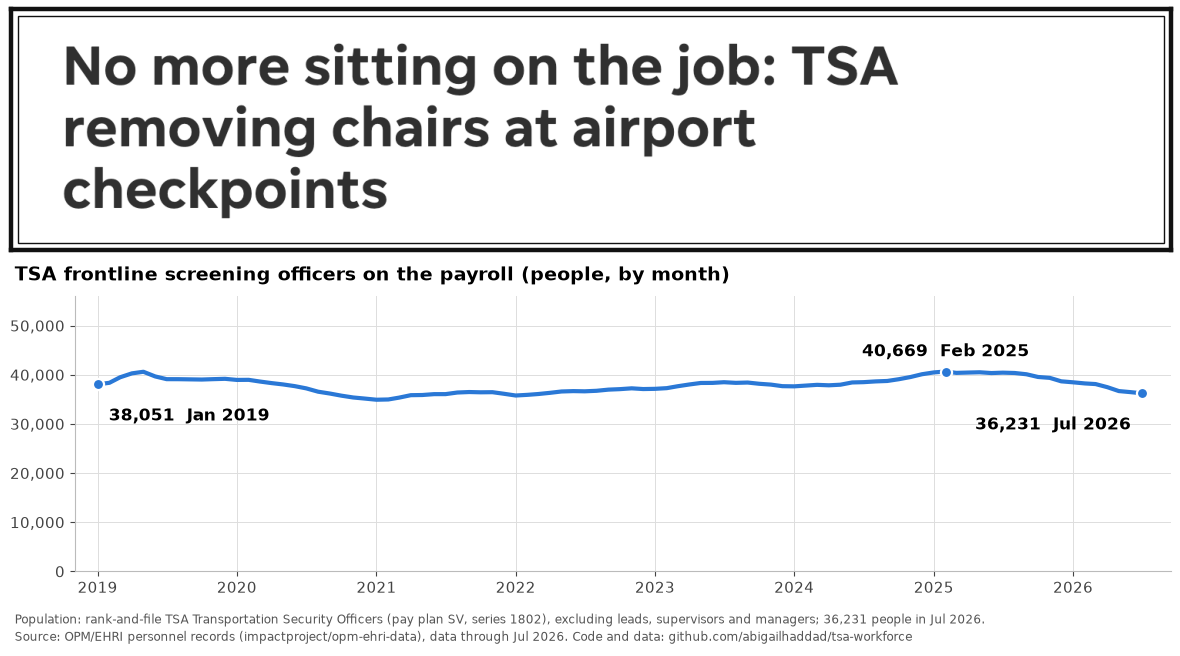

In [4]:
from matplotlib.patches import Rectangle
HEADLINE = plt.imread("assets/headline.png")[105:, :-26]      # keep the headline lines only: drop the site's top row (section label, topic button) and a stray right-hand border
W_PX, H_PX, M, PAD = 1200, 675, 20, 16                          # image size, outer margin, padding inside the frame (pixels)
fx = lambda x: x / W_PX
fy = lambda y: 1 - y / H_PX                                     # y measured down from the top, in pixels
fig = plt.figure(figsize=(W_PX / 100, H_PX / 100), dpi=100)

# the headline, framed: heavy outer rule plus a hairline inside it
box_w = W_PX - 2 * M; img_w = box_w - 2 * PAD; img_h = img_w * HEADLINE.shape[0] / HEADLINE.shape[1]; box_h = img_h + 2 * PAD
ax_box = fig.add_axes([fx(M), fy(M + box_h), box_w / W_PX, box_h / H_PX]); ax_box.set_facecolor("white"); ax_box.set_xticks([]); ax_box.set_yticks([])
for sp in ax_box.spines.values(): sp.set_visible(True); sp.set_linewidth(3.2); sp.set_color("#111111")      # the notebook hides top/right spines by default; the frame needs all four
ax_box.add_patch(Rectangle((7 / box_w, 7 / box_h), 1 - 14 / box_w, 1 - 14 / box_h, transform=ax_box.transAxes, fill=False, ec="#111111", lw=1))
ax_img = fig.add_axes([fx(M + PAD), fy(M + PAD + img_h), img_w / W_PX, img_h / H_PX]); ax_img.imshow(HEADLINE); ax_img.axis("off")

# the chart: a wide band under the headline
top = M + box_h + 16
fig.text(fx(M + 4), fy(top), "TSA frontline screening officers on the payroll (people, by month)", fontsize=13.5, fontweight="bold", va="top")
ax_top, ax_bot = top + 30, 582
axl = fig.add_axes([fx(84), fy(ax_bot), (W_PX - M - 84) / W_PX, (ax_bot - ax_top) / H_PX])
axl.plot(hcf.date, hcf.n, lw=3, color=C_TSA)
for x_, y_ in ((hcf.date.iloc[-1], hcf.n.iloc[-1]), (pk_date, pk_.n), (hcf.date.iloc[0], hcf.n.iloc[0])): axl.plot(x_, y_, "o", ms=8, color=C_TSA, markeredgecolor="white", markeredgewidth=1.6)
axl.annotate(f"{int(hcf.n.iloc[0]):,}  {ym_label(hcf.snapshot_ym.iloc[0])}", (hcf.date.iloc[0], hcf.n.iloc[0]), xytext=(8, -26), textcoords="offset points", ha="left", fontsize=12, fontweight="bold")
axl.annotate(f"{int(pk_.n):,}  {ym_label(pk_.snapshot_ym)}", (pk_date, pk_.n), xytext=(0, 11), textcoords="offset points", ha="center", fontsize=12, fontweight="bold")
axl.annotate(f"{int(hcf.n.iloc[-1]):,}  {ym_label(hcf.snapshot_ym.iloc[-1])}", (hcf.date.iloc[-1], hcf.n.iloc[-1]), xytext=(-8, -26), textcoords="offset points", ha="right", fontsize=12, fontweight="bold")
axl.set_ylim(0, 56000); comma_y(axl); date_x(axl); axl.tick_params(labelsize=11)
axl.set_xlim(hcf.date.min() - pd.Timedelta(days=60), hcf.date.max() + pd.Timedelta(days=75))
foot = chr(10).join(textwrap.wrap(f"Population: rank-and-file TSA Transportation Security Officers (pay plan SV, series 1802), excluding leads, supervisors and managers; {FRONT_N:,} people in {ym_label(LATEST)}.", 175)
                    + textwrap.wrap(f"Source: OPM/EHRI personnel records (impactproject/opm-ehri-data), data through {ym_label(LATEST)}. Code and data: {tsa.REPO_URL}", 175))
fig.text(fx(M + 4), fy(622), foot, fontsize=8.6, color="#555555", va="top", linespacing=1.45)
with plt.rc_context({"savefig.bbox": "standard"}):      # the notebook crops saved charts by default; this one must be exactly 1200 x 675
    fig.savefig(FIG / "linkedin.png", dpi=100)
plt.show()

## 0. Method checks

Every assumption this analysis leans on is checked against the data live below, not just asserted.
Ten checks: TSA's agency code is the only one and is stable (①), monthly files add new actions rather than
restating old ones (②), recent months are incomplete and we measure by how much (③), the headcount series
has no gaps (④), TSA's "hires" are genuine new hires only (⑤), headcount and flows reconcile only
roughly (⑥), buyout-program exits are separable (⑦), OPM's release notes say nothing that would distort TSA (⑧),
our extract matches OPM's original files (⑨), and the national passenger counts are complete and agree with TSA's other publication of them (⑩).

In [5]:
# CHECK 1 — agency identity & code stability. Built offline by src/history.py: EVERY subelement whose name
# mentions transportation / security administration / TSA, in a sample of months 2005-2026.
aud = pd.read_csv("data/agency_code_audit.csv", dtype={"snapshot_ym": str})
piv = aud.pivot_table(index=["code", "name"], columns="snapshot_ym", values="headcount", aggfunc="sum").fillna(0)
show(piv.reset_index())

code,name,200506,200806,201006,201206,201406,201606,201806,202006,202206,202406,202506,202606
AF3T,"AIR FORCE ELEMENTS, U.S. TRANSPORTATION COMMAND",348,399,483,576,637,661,748,884,960,994,"1,002",968
ARXT,ARMY TRANSPORTATION COMMAND,0,0,0,0,0,0,0,0,0,0,0,"1,132"
BT00,ARCHITECTURAL AND TRANSPORTATION BARRIERS COMPLIANCE BOARD,40,41,40,40,40,41,37,40,43,39,37,33
DD29,DEFENSE TECHNOLOGY SECURITY ADMINISTRATION,134,141,135,132,127,129,126,125,117,122,120,0
DF00,OFFICE OF THE FEDERAL COORDINATOR FOR ALASKA NATURAL GAS TRANSPORTATION PROJECTS,0,4,11,6,5,0,0,0,0,0,0,0
DLPW,EMPLOYEE BENEFITS SECURITY ADMINISTRATION,879,0,994,"1,000",990,968,842,851,797,835,769,614
HSBA,OFFICE OF THE UNDER SECRETARY FOR BORDER AND TRANSPORTATION SECURITY,146,0,0,0,0,0,0,0,0,0,0,0
HSBC,TRANSPORTATION SECURITY ADMINISTRATION,"57,948","61,476","59,970","65,209","60,831","59,625","62,260","62,219","60,957","63,701","65,943","59,977"
SZ00,SOCIAL SECURITY ADMINISTRATION,"66,842","63,622","69,600","65,282","62,651","65,352","60,898","60,515","58,332","58,367","52,834","49,439"
TB00,NATIONAL TRANSPORTATION SAFETY BOARD,431,403,392,429,407,442,414,404,408,436,408,406


In [6]:
codes = aud.groupby("code").snapshot_ym.nunique()
tsa_names = aud[aud.code == tsa.TSA].name.unique()
n_months_audited = aud.snapshot_ym.nunique()
print(f"Audited {n_months_audited} sampled snapshot months, 2005-2026.")
print(f"HSBC appears in {codes.get(tsa.TSA, 0)} of them under name(s): {list(tsa_names)}")
print("Other codes whose name matched the search (separate agencies, NOT TSA):",
      sorted(set(aud.code) - {tsa.TSA}) or "none")

Audited 12 sampled snapshot months, 2005-2026.
HSBC appears in 12 of them under name(s): ['TRANSPORTATION SECURITY ADMINISTRATION']
Other codes whose name matched the search (separate agencies, NOT TSA): ['AF3T', 'ARXT', 'BT00', 'DD29', 'DF00', 'DLPW', 'HSBA', 'SZ00', 'TB00', 'TD01', 'TD15', 'TW00']


In [7]:
# CHECK 2 — files add new actions, they don't re-state the whole history. For a normal month and for the
# month whose separations landed late (Oct 2025), show how that month's TSA separations split across the files
# that reported them. If files re-stated history, one file would hold ~100% every time.
rows = []
for ym in ["202403", "202510"]:
    d = q(f"SELECT file_ym, SUM(count) n FROM '{SEP}' WHERE event_ym='{ym}' GROUP BY 1 ORDER BY 1")
    d["event month"] = ym_label(ym); d["share_%"] = 100 * d.n / d.n.sum()
    rows.append(d[["event month", "file_ym", "n", "share_%"]].head(6))
show(pd.concat(rows).rename(columns={"file_ym": "reported in file", "n": "TSA separations"}), pct=["share_%"])

event month,reported in file,TSA separations,share_%
Mar 2024,202403,392,99.0%
Mar 2024,202404,4,1.0%
Oct 2025,202510,14,1.7%
Oct 2025,202511,638,77.5%
Oct 2025,202512,63,7.7%
Oct 2025,202601,71,8.6%
Oct 2025,202602,7,0.9%
Oct 2025,202603,20,2.4%


In [8]:
# CHECK 3 — how complete is a month after k months? Measured on settled months (Jan-Nov 2024, 20+ months of
# later files behind them), for TSA hires and TSA separations separately.
def completeness(table, lo, hi, extra="1=1"):
    return q(f"""
      WITH x AS (SELECT event_ym, SUM(count) n,
          (CAST(substr(file_ym,1,4) AS INT)*12+CAST(substr(file_ym,5,2) AS INT))
         -(CAST(substr(event_ym,1,4) AS INT)*12+CAST(substr(event_ym,5,2) AS INT)) AS lag
        FROM '{table}' WHERE event_ym BETWEEN '{lo}' AND '{hi}' AND {extra} GROUP BY 1, file_ym)
      SELECT lag, SUM(n) n, ROUND(100.0*SUM(SUM(n)) OVER (ORDER BY lag)/(SELECT SUM(n) FROM x),1) AS cum_pct
      FROM x WHERE lag BETWEEN 0 AND 5 GROUP BY lag ORDER BY lag""")
c_sep = completeness(SEP, "202401", "202411"); c_acc = completeness(ACC, "202401", "202411")
tab = c_sep[["lag", "cum_pct"]].rename(columns={"cum_pct": "separations: % of final total present"}).merge(
      c_acc[["lag", "cum_pct"]].rename(columns={"cum_pct": "hires: % of final total present"}), on="lag", how="outer")
show(tab.rename(columns={"lag": "Months after the month"}), pct=list(tab.columns[1:]))

Months after the month,separations: % of final total present,hires: % of final total present
0,99.6%,99.5%
1,99.8%,99.6%
2,99.9%,99.6%
3,99.9%,99.7%
4,99.9%,99.8%
5,—,99.8%


In [9]:
# ...but the Oct 2025 - Feb 2026 separations did NOT land that fast. Same curve, those months (now 5+ months settled):
late = completeness(SEP, "202510", "202602")
show(late[["lag", "cum_pct"]].rename(columns={"lag": "Months after the month", "cum_pct": "separations, Oct 2025-Feb 2026: % present"}),
     pct=["separations, Oct 2025-Feb 2026: % present"])
print(f"=> A normal month is {c_sep.cum_pct.iloc[0]:.0f}% complete in its own file. The Oct 2025 - Feb 2026 separations were late-landing: only {late.cum_pct.iloc[0]:.0f}% were in their own month's file.")
print("   Recent months may still be filling in, so the notebook marks them as provisional and never anchors a conclusion on the last few months alone.")

=> A normal month is 100% complete in its own file. The Oct 2025 - Feb 2026 separations were late-landing: only 23% were in their own month's file.
   Recent months may still be filling in, so the notebook marks them as provisional and never anchors a conclusion on the last few months alone.


In [10]:
# CHECK 4 — headcount snapshots: one per file, and no missing months in 2018-2026.
snaps = q(f"SELECT DISTINCT snapshot_ym FROM '{EMP}' ORDER BY 1").snapshot_ym.tolist()
expected = [f"{y}{m:02d}" for y in range(2018, 2027) for m in range(1, 13) if f"{y}{m:02d}" <= LATEST]
fm_emp = [k for k in tsa.file_map()["employment"] if "201801" <= k <= LATEST]
print(f"Employment: {len(fm_emp)} files in OPM's current list for 2018-01..{LATEST}; {len(snaps)} distinct snapshot months in the extract; "
      f"missing from the extract: {sorted(set(expected) - set(snaps)) or 'none'}")
dup = scalar(f"SELECT COUNT(*) FROM (SELECT snapshot_ym, COUNT(DISTINCT 1) FROM '{EMP}' GROUP BY 1) WHERE 1=0")
mx = q(f"SELECT snapshot_ym, SUM(count) hc FROM '{EMP}' GROUP BY 1 ORDER BY 1")
print(f"Headcount range across all {len(mx)} snapshots: {int(mx.hc.min()):,} to {int(mx.hc.max()):,}; "
      f"largest one-month change: {int(mx.hc.diff().abs().max()):,}")

Employment: 103 files in OPM's current list for 2018-01..202607; 103 distinct snapshot months in the extract; missing from the extract: none
Headcount range across all 103 snapshots: 59,004 to 66,327; largest one-month change: 1,281


In [11]:
# CHECK 5 — what does TSA's accessions file contain? A file with a "transfer in" category would let us separate new hires from
# transfers. Check which accession categories TSA records at all.
tsa_cats = q(f"SELECT accession_category, SUM(count) n FROM '{ACC}' GROUP BY 1 ORDER BY 2 DESC")
display(Markdown("**TSA accession categories, 2018-2026**")); display(show(tsa_cats))
share_front_hires = 100 * scalar(f"SELECT SUM(CASE WHEN {OFFICER} THEN count END)/SUM(count) FROM '{ACC}'")
print(f"TSA records {len(tsa_cats)} accession category ({tsa_cats.accession_category.iloc[0].title()}). So these 'hires' are genuine new hires, but if TSA ever received a transfer in from "
      f"another agency it is not recorded under a transfer category here (§6). {share_front_hires:.0f}% of TSA's 2018-2026 hires are frontline officers (SV-1802, rank-and-file).")

**TSA accession categories, 2018-2026**

accession_category,n
NEW HIRE - EXCEPTED SERVICE APPOINTMENT,"70,376"


TSA records 1 accession category (New Hire - Excepted Service Appointment). So these 'hires' are genuine new hires, but if TSA ever received a transfer in from another agency it is not recorded under a transfer category here (§6). 93% of TSA's 2018-2026 hires are frontline officers (SV-1802, rank-and-file).


In [12]:
# CHECK 6 — headcount vs hires-minus-separations, month by month. They should roughly agree.
recon = q(f"""
  WITH e AS (SELECT snapshot_ym ym, SUM(count) hc FROM '{EMP}' GROUP BY 1),
       a AS (SELECT event_ym ym, SUM(count) hires FROM '{ACC}' GROUP BY 1),
       s AS (SELECT event_ym ym, SUM(count) seps FROM '{SEP}' GROUP BY 1)
  SELECT e.ym, hc, hc - LAG(hc) OVER (ORDER BY e.ym) AS d_headcount, hires, seps, hires - seps AS net_flow
  FROM e LEFT JOIN a USING(ym) LEFT JOIN s USING(ym) ORDER BY e.ym""")
recon["gap"] = recon.d_headcount - recon.net_flow
recon["year"] = recon.ym.str[:4]
yr = recon[recon.ym > "201801"].groupby("year").agg(d_headcount=("d_headcount", "sum"), net_flow=("net_flow", "sum"), gap=("gap", "sum"))
yr["gap_%_of_headcount_change"] = (100 * yr.gap / yr.d_headcount.abs()).round(0)
display(show(yr.reset_index().rename(columns={"year": "Year", "d_headcount": "Headcount change", "net_flow": "Hires - separations", "gap": "Unexplained gap"}), pct=[]))
since = recon[(recon.ym > "202502")]
g_hc, g_flow = int(since.d_headcount.sum()), int(since.net_flow.sum())
neg_years = int((yr.gap < 0).sum())
print(f"Mar 2025 -> {ym_label(LATEST)}: headcount {g_hc:+,}; hires - separations {g_flow:+,}; unexplained {g_hc-g_flow:+,} "
      f"({100*(g_hc-g_flow)/g_hc:.0f}% of the headcount change).")
print(f"The gap is not new: hires - separations overstated the headcount change in {neg_years} of {len(yr)} years (2018 omits January). "
      f"So it is a standing feature of how the files fit together, not something that appeared with the 2025-26 decline. "
      f"We use headcount for LEVELS and flows for RATES; we never chain them.")

Year,Headcount change,Hires - separations,Unexplained gap,gap_%_of_headcount_change
2018,"2,169","2,657",-488,-22
2019,990,"2,148","-1,158",-117
2020,"-4,481","-3,534",-947,-21
2021,680,553,127,19
2022,"1,359","2,007",-648,-48
2023,907,"1,954","-1,047",-115
2024,"3,459","3,764",-305,-9
2025,"-2,799","-2,701",-98,-4
2026,"-3,395","-2,544",-851,-25


Mar 2025 -> Jul 2026: headcount -6,716; hires - separations -5,741; unexplained -975 (15% of the headcount change).
The gap is not new: hires - separations overstated the headcount change in 8 of 9 years (2018 omits January). So it is a standing feature of how the files fit together, not something that appeared with the 2025-26 decline. We use headcount for LEVELS and flows for RATES; we never chain them.


In [13]:
# CHECK 7 — buyout (deferred resignation program) exits. 2025 retirements/separations were inflated by DRP.
# drp_indicator exists on separations only. How many TSA exits are flagged, and when?
drp = q(f"SELECT substr(event_ym,1,4) y, SUM(CASE WHEN drp_indicator='Y' THEN count END) drp_y, SUM(CASE WHEN drp_indicator='N' THEN count END) drp_n, SUM(CASE WHEN drp_indicator IS NULL THEN count END) drp_null, SUM(count) total FROM '{SEP}' WHERE event_ym >= '201801' GROUP BY 1 ORDER BY 1")
display(show(drp.rename(columns={"y": "Year", "drp_y": "Flagged DRP", "drp_n": "Not DRP", "drp_null": "Flag missing", "total": "All separations"})))
drp_m = q(f"SELECT event_ym, separation_category, SUM(count) n FROM '{SEP}' WHERE drp_indicator='Y' GROUP BY 1,2 ORDER BY 1,2")
print("DRP-flagged TSA exits by month:", {r.event_ym: int(r.n) for r in drp_m.groupby('event_ym').n.sum().reset_index().itertuples()})
print("The flag is populated 'N' in every year before 2025 (never missing), so 2018-2024 are simply 'no DRP exits'.")

Year,Flagged DRP,Not DRP,Flag missing,All separations
2018,—,"8,575",—,"8,575"
2019,—,"8,849",—,"8,849"
2020,—,"5,891",—,"5,891"
2021,—,"8,597",—,"8,597"
2022,—,"9,710",—,"9,710"
2023,—,"6,685",—,"6,685"
2024,—,"5,517",—,"5,517"
2025,645,"7,518",—,"8,163"
2026,—,"4,104",—,"4,104"


DRP-flagged TSA exits by month: {'202507': 1, '202509': 440, '202510': 202, '202511': 1, '202512': 1}
The flag is populated 'N' in every year before 2025 (never missing), so 2018-2024 are simply 'no DRP exits'.


In [14]:
# CHECK 8 — did OPM's release notes (fetched when build_file_map.py ran, saved at data/release_notes.txt) say anything
# that would distort TSA numbers? Search them for TSA, Homeland Security, and the pay plan.
import re
rn = open("data/release_notes.txt").read()
hits = {k: len(re.findall(k, rn, flags=re.I)) for k in ["TSA", "Transportation Security", "Homeland", "DHS", "HSBC", "screening officer"]}
print(f"Mentions in OPM's release notes (page fetched {tsa.ASOF}, {len(rn):,} characters):", hits)

Mentions in OPM's release notes (page fetched 2026-10-01, 17,227 characters): {'TSA': 0, 'Transportation Security': 0, 'Homeland': 0, 'DHS': 0, 'HSBC': 0, 'screening officer': 0}


In [15]:
# CHECK 9 — does our extract match OPM's original files? src/verify.py downloads each sampled file from OPM's API
# AND from the HuggingFace mirror, compares them as an order-independent set of rows, recounts TSA rows with a different
# reader (pyarrow), and compares the columns this analysis uses to our extract. 14 fixed edge cases + 12 random files.
pf = pd.read_csv("data/proof_sample.csv", dtype={"month": str})
yn = pf.copy()
for c in ["tsa_columns_used_identical", "opm_equals_mirror_exact", "opm_equals_mirror_normalized"]: yn[c] = yn[c].map({True: "yes", False: "NO"})
display(show(yn[["dataset", "month", "version", "tsa_count_opm", "tsa_count_ours", "tsa_columns_used_identical", "opm_equals_mirror_exact", "opm_equals_mirror_normalized", "null_like_cells_in_tsa_rows"]]
             .rename(columns={"tsa_count_opm": "TSA count, OPM original", "tsa_count_ours": "TSA count, our extract", "tsa_columns_used_identical": "TSA rows, used columns identical",
                              "opm_equals_mirror_exact": "Mirror == OPM, exact", "opm_equals_mirror_normalized": "Mirror == OPM, blanks folded", "null_like_cells_in_tsa_rows": "Blank/NA cells in TSA rows"})))
print(f"{len(pf)} files checked. Extract matches OPM's original (TSA rows, on every column we use): {int(pf.tsa_columns_used_identical.sum())} of {len(pf)}. "
      f"Mirror identical to OPM: {int(pf.opm_equals_mirror_exact.sum())} exactly, {int(pf.opm_equals_mirror_normalized.sum())} once blank-like cells are folded together.")
print("'Blanks folded' means: whitespace stripped, then an empty string, the text 'NA' and NULL are treated as the same value; rows are compared as an unordered set. Details: src/verify.py.")

dataset,month,version,"TSA count, OPM original","TSA count, our extract","TSA rows, used columns identical","Mirror == OPM, exact","Mirror == OPM, blanks folded",Blank/NA cells in TSA rows
employment,201801,3,"60,722","60,722",yes,NO,yes,"1,774"
employment,202502,3,"66,327","66,327",yes,NO,yes,"1,130"
employment,202510,3,"64,348","64,348",yes,NO,yes,908
employment,202606,2,"59,977","59,977",yes,yes,yes,849
employment,202607,1,"59,611","59,611",yes,yes,yes,858
accessions,201801,3,745,745,yes,NO,yes,"1,500"
accessions,202512,3,30,30,yes,NO,yes,59
accessions,202606,3,224,224,yes,yes,yes,448
accessions,202607,1,439,439,yes,yes,yes,879
separations,201801,3,769,769,yes,NO,yes,"1,546"


26 files checked. Extract matches OPM's original (TSA rows, on every column we use): 26 of 26. Mirror identical to OPM: 6 exactly, 26 once blank-like cells are folded together.
'Blanks folded' means: whitespace stripped, then an empty string, the text 'NA' and NULL are treated as the same value; rows are compared as an unordered set. Details: src/verify.py.


In [16]:
# CHECK 10 — the national daily passenger counts (src/fetch_throughput.py): complete, and consistent with TSA's other publication of the
# same thing. src/check_throughput.py sums TSA's weekly hourly throughput files (one row per airport, checkpoint and hour, in the FOIA
# reading room) for four fixed weeks and compares each to the daily table for the same seven days.
pax_all = pd.read_csv(tsa.PAX, parse_dates=["date"])
gaps = pd.date_range(pax_all.date.min(), pax_all.date.max()).difference(pax_all.date)
print(f"Daily table: {len(pax_all):,} days, {pax_all.date.min().date()} to {pax_all.date.max().date()}; duplicate days: {int(pax_all.date.duplicated().sum())}; missing days: {len(gaps)}.")
xc = pd.read_csv("data/throughput_crosscheck.csv")
xc["weekly file as % of daily table"] = 100 * xc.file_over_table
display(show(xc[["week", "file_total", "daily_table_total", "weekly file as % of daily table"]].rename(columns={"week": "Week", "file_total": "Weekly hourly file, total", "daily_table_total": "Daily table, same 7 days"}),
             pct=["weekly file as % of daily table"]))
print(f"The two TSA publications agree to within {100*(1-xc.file_over_table.min()):.0f}% in every week checked (the hourly file is lower each time: {100*xc.file_over_table.min():.0f}-{100*xc.file_over_table.max():.0f}% of the daily table). "
      "Both are TSA's; the gap means they cover slightly different things (or my parse of the PDF misses some rows), not that one is right. The daily table is TSA's headline series and is what the notebook uses.")

Daily table: 2,830 days, 2019-01-01 to 2026-09-30; duplicate days: 0; missing days: 0.


Week,"Weekly hourly file, total","Daily table, same 7 days",weekly file as % of daily table
2024-03-03 to 2024-03-09,"16,145,540","16,808,957",96.1%
2025-03-02 to 2025-03-08,"15,761,635","16,479,496",95.6%
2026-03-01 to 2026-03-07,"15,508,936","16,815,144",92.2%
2026-07-12 to 2026-07-18,"18,110,397","18,918,179",95.7%


The two TSA publications agree to within 8% in every week checked (the hourly file is lower each time: 92-96% of the daily table). Both are TSA's; the gap means they cover slightly different things (or my parse of the PDF misses some rows), not that one is right. The daily table is TSA's headline series and is what the notebook uses.


With the method checked, the findings follow. Everything below is the frontline officer group defined above, unless it says otherwise.

## 1. Is TSA hiring officers?

New frontline officers per calendar year. The current year is partial (Jan–Jul). The "replacement ratio" is hires divided by
separations in the same year: above 1 the agency is adding people, below 1 it is shrinking.

In [17]:
H = q(f"SELECT substr(event_ym,1,4) AS year, SUM(count) AS hires FROM '{ACC}' WHERE {OFFICER} GROUP BY 1")
S = q(f"SELECT substr(event_ym,1,4) AS year, SUM(count) AS seps FROM '{SEP}' WHERE {OFFICER} GROUP BY 1")
yearly = H.merge(S, on="year"); yearly["replacement_ratio"] = (yearly.hires / yearly.seps).round(2)
yearly = yearly[yearly.year >= "2018"].sort_values("year").reset_index(drop=True)
show(yearly.rename(columns={"year": "Year", "hires": "Officers hired", "seps": "Officers who left", "replacement_ratio": "Hired ÷ left"}))

Year,Officers hired,Officers who left,Hired ÷ left
2018,"11,080","7,088",1.6
2019,"10,820","7,449",1.4
2020,"2,116","4,687",0.5
2021,"8,834","6,942",1.3
2022,"10,692","7,395",1.4
2023,"7,344","5,233",1.4
2024,"7,833","4,144",1.9
2025,"5,297","5,853",0.9
2026,"1,457","3,026",0.5


In [18]:
y = yearly.set_index("year")
norm = y.loc["2022":"2024", "hires"]
assert list(y.index) == sorted(y.index) and len(norm) == 3
h25, h26 = int(y.loc["2025", "hires"]), int(y.loc["2026", "hires"])
display(Markdown(
    f"TSA hired **{int(norm.min()):,}–{int(norm.max()):,} frontline officers a year in 2022–2024**. In **2025 it hired {h25:,}**, "
    f"{100*(1-h25/norm.mean()):.0f}% below that three-year average, and in the first {YEARS_PARTIAL} months of 2026 "
    f"it hired {h26:,} — a pace of about {h26*12/YEARS_PARTIAL:,.0f} a year. 2025 was also the first year since 2020 in which "
    f"hires fell below separations (ratio {y.loc['2025','replacement_ratio']}); in 2026 the ratio is {y.loc['2026','replacement_ratio']}."))

TSA hired **7,344–10,692 frontline officers a year in 2022–2024**. In **2025 it hired 5,297**, 39% below that three-year average, and in the first 7 months of 2026 it hired 1,457 — a pace of about 2,498 a year. 2025 was also the first year since 2020 in which hires fell below separations (ratio 0.91); in 2026 the ratio is 0.48.

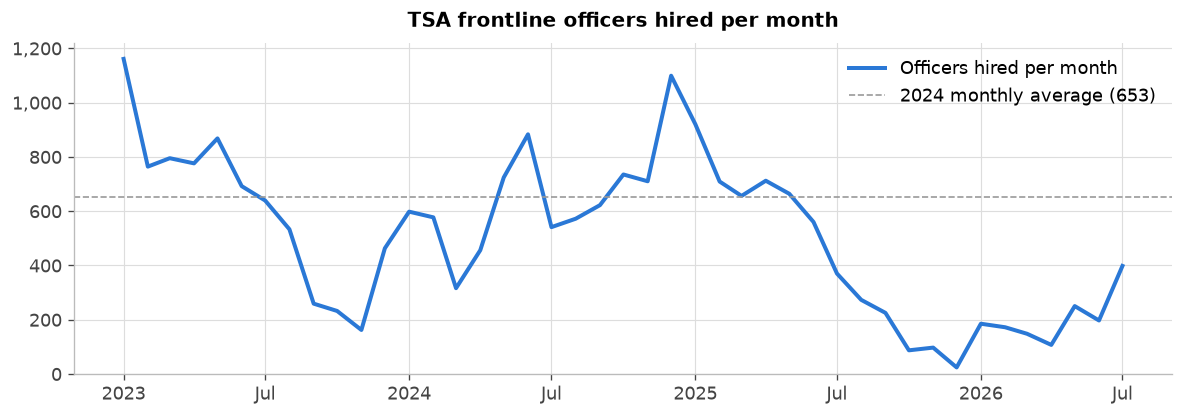

In [19]:
# Monthly officer hiring against the officers' own 2024 monthly average.
m_tsa = q(f"SELECT event_ym, SUM(count) n FROM '{ACC}' WHERE {OFFICER} AND event_ym >= '202301' GROUP BY 1 ORDER BY 1")
b_tsa = m_tsa[m_tsa.event_ym.str[:4] == "2024"].n.mean()
m_tsa["date"] = pd.to_datetime(m_tsa.event_ym, format="%Y%m"); m_tsa["pct"] = 100 * m_tsa.n / b_tsa
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(m_tsa.date, m_tsa.n, lw=2.4, color=C_TSA, label="Officers hired per month")
ax.axhline(b_tsa, color="#999", lw=1, ls="--", label=f"2024 monthly average ({b_tsa:,.0f})")
ax.set_ylim(0, None); comma_y(ax); date_x(ax); ax.legend(loc="upper right"); ax.set_title("TSA frontline officers hired per month"); fig.tight_layout()

In [20]:
tsa_after = m_tsa[(m_tsa.event_ym >= "202508") & (m_tsa.event_ym <= "202606")].pct.mean()
display(Markdown(
    f"From Aug 2025 through Jun 2026, monthly officer hiring averaged **{tsa_after:.0f}%** of its 2024 level. "
    f"Monthly hires bottomed at **{int(m_tsa.n.min()):,} ({ym_label(m_tsa.loc[m_tsa.n.idxmin(), 'event_ym'])})** and have recovered somewhat since, "
    f"to **{int(m_tsa.n.iloc[-1]):,} in {ym_label(LATEST)}**. Hiring stayed near its 2024 level through spring 2025 and fell from July 2025 on."))

From Aug 2025 through Jun 2026, monthly officer hiring averaged **25%** of its 2024 level. Monthly hires bottomed at **24 (Dec 2025)** and have recovered somewhat since, to **398 in Jul 2026**. Hiring stayed near its 2024 level through spring 2025 and fell from July 2025 on.

### 1b. Context: TSA's officer hiring since 2005

Extending back to 2006 (from the raw yearly files, `src/history.py`; in 2005 officers were not yet coded as SV-1802) shows whether 2025 is unusual for TSA or just
another low year. 2020 (the pandemic) is the obvious comparison.

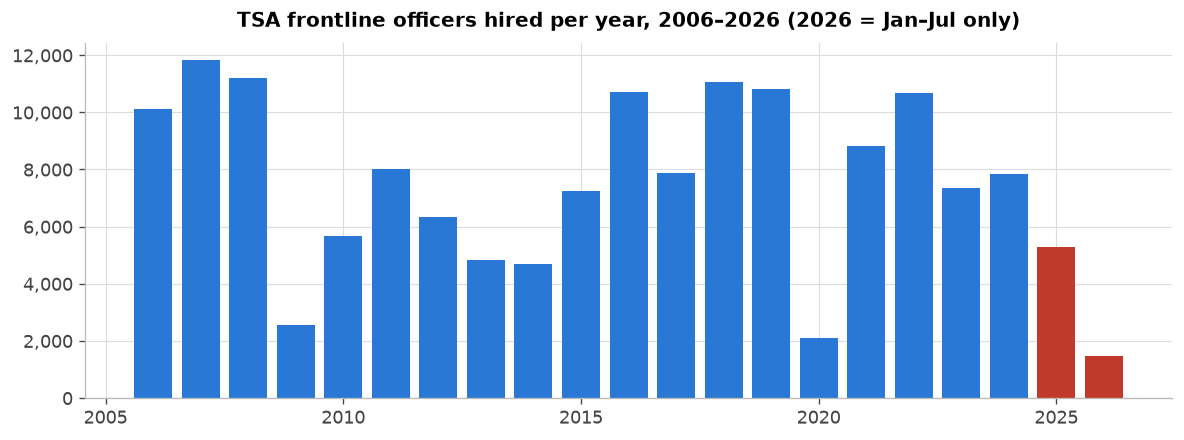

In [21]:
hist = pd.read_csv("data/tsa_hires_history.csv", dtype={"year": str})
hh = hist[hist.kind == "accessions_frontline"].set_index("year").n
hh = hh[hh.index >= "2006"]       # 2005: officers were not yet coded SV-1802 (3 of 7,343 hires), so the series starts in 2006
long = pd.concat([hh, yearly.set_index("year").hires]).astype(float)
long.index = long.index.astype(int); long = long.sort_index()
fig, ax = plt.subplots(figsize=(10, 3.8))
colors = [C_MUTED if y in (2025, 2026) else C_TSA for y in long.index]
ax.bar(long.index, long.values, color=colors); comma_y(ax)
ax.set_title("TSA frontline officers hired per year, 2006–2026 (2026 = Jan–Jul only)")
fig.tight_layout()

In [22]:
full = long.loc[:2025]                                  # complete years only
rank = int((full <= long.loc[2025]).sum())              # 1 = lowest
lo_year = full.loc[:2024].idxmin()
pace26 = long.loc[2026] * 12 / YEARS_PARTIAL
display(Markdown(
    f"Of the {len(full)} complete years {full.index.min()}–2025, 2025 ({int(long.loc[2025]):,} hires) is the **{rank}{'st' if rank==1 else 'nd' if rank==2 else 'rd' if rank==3 else 'th'}-lowest**. "
    f"The lowest before it was **{lo_year}** ({int(long.loc[lo_year]):,}). 2026's seven months ({int(long.loc[2026]):,}) are on a pace of about {pace26:,.0f} a year — "
    f"{'below' if pace26 < long.loc[:2025].min() else 'above'} the lowest complete year in the series ({int(long.loc[:2025].min()):,}, {long.loc[:2025].idxmin()}); "
    f"that pace is a straight-line extrapolation from seven months and could change."))

Of the 20 complete years 2006–2025, 2025 (5,297 hires) is the **5th-lowest**. The lowest before it was **2020** (2,116). 2026's seven months (1,457) are on a pace of about 2,498 a year — above the lowest complete year in the series (2,116, 2020); that pace is a straight-line extrapolation from seven months and could change.

## 2. Is the officer workforce shrinking?

Headcount is the *level*: how many people are on the payroll in each month's snapshot. It is the authoritative series (§0 check 6).

In [23]:
hc = q(f"SELECT snapshot_ym, SUM(CASE WHEN {OFFICER} THEN count END) AS front, SUM(count) AS all_tsa FROM '{EMP}' GROUP BY 1 ORDER BY 1")
pk = hc[hc.snapshot_ym >= "202401"].loc[lambda d: d.front.idxmax()]
pre_min = hc[hc.snapshot_ym < "202501"].loc[lambda d: d.front.idxmin()]
last = hc.iloc[-1]; mar26 = hc[hc.snapshot_ym == "202603"].iloc[0]
rises = ", ".join(ym_label(r.snapshot_ym) for r in hc[hc.snapshot_ym > pk.snapshot_ym].assign(d=lambda d: d.front.diff()).query("d > 0").itertuples()) or "none"
display(Markdown(
    f"TSA's frontline officer headcount peaked at **{int(pk.front):,} in {ym_label(pk.snapshot_ym)}** and was **{int(last.front):,} in {ym_label(LATEST)}** — "
    f"down **{int(pk.front - last.front):,} ({100*(1-last.front/pk.front):.1f}%)**, and down {100*(1-last.front/mar26.front):.1f}% since March 2026 alone. "
    f"(All TSA employees: {int(pk.all_tsa):,} to {int(last.all_tsa):,}, down {100*(1-last.all_tsa/pk.all_tsa):.1f}%.) "
    f"Officer headcount has fallen in every month since {ym_label(pk.snapshot_ym)} except {rises}. "
    f"For scale, its lowest month in 2018–2024 was {int(pre_min.front):,} ({ym_label(pre_min.snapshot_ym)}, the pandemic trough); {ym_label(LATEST)} is {int(last.front) - int(pre_min.front):,} above that."))

TSA's frontline officer headcount peaked at **40,669 in Feb 2025** and was **36,231 in Jul 2026** — down **4,438 (10.9%)**, and down 4.9% since March 2026 alone. (All TSA employees: 66,327 to 59,611, down 10.1%.) Officer headcount has fallen in every month since Feb 2025 except Apr 2025, May 2025, Jul 2025. For scale, its lowest month in 2018–2024 was 34,926 (Jan 2021, the pandemic trough); Jul 2026 is 1,305 above that.

## 3. How much passenger volume is there per officer?

TSA does not publish checkpoint wait times (it records them hourly at every checkpoint, but only reports a summary), so how long the lines are cannot be measured here.
It does publish how many passengers it screens each day (§0 check 10). Dividing by the officers on the payroll gives a rough workload index: **passengers screened per day, per frontline officer**.
It is not how many people each officer screens: not every passenger meets every officer, the counts include airports where private contractors do the screening, and part-time officers count as one head.
It shows whether the volume each officer's share of the system has to handle is rising or falling. The chart is the bottom panel of the figure at the top of the notebook.

In [24]:
def chg(a, b, col): return 100 * (wl.loc[b, col] / wl.loc[a, col] - 1)
display(Markdown(
    f"In {ym_label(last_m)} TSA screened an average of {wl.loc[last_m, 'per_day']:,.0f} passengers a day with {int(wl.loc[last_m, 'officers']):,} frontline officers on the payroll: "
    f"**{wl.loc[last_m, 'per_officer']:.1f} passengers per officer per day**. A year earlier ({ym_label(prev_m)}) it was {wl.loc[prev_m, 'per_officer']:.1f}: passengers per day {chg(prev_m, last_m, 'per_day'):+.1f}%, "
    f"officers {chg(prev_m, last_m, 'officers'):+.1f}%, passengers per officer {chg(prev_m, last_m, 'per_officer'):+.1f}%. "
    + (f"Against the same month before the pandemic ({ym_label(base_m)}: {wl.loc[base_m, 'per_officer']:.1f}) it is {chg(base_m, last_m, 'per_officer'):+.1f}%." if base_m in wl.index else "")))

In Jul 2026 TSA screened an average of 2,688,392 passengers a day with 36,231 frontline officers on the payroll: **74.2 passengers per officer per day**. A year earlier (Jul 2025) it was 67.9: passengers per day -2.1%, officers -10.4%, passengers per officer +9.3%. Against the same month before the pandemic (Jul 2019: 65.0) it is +14.1%.

## 4. How complete are the most recent months?

Separations are reported late, so the most recent months are provisional: they can only gain separations as later files arrive (§0 check 3).
This matters for the departures line in the chart at the top and for the 2026 figures below.

In [25]:
# How much could the provisional months still move? Two completeness curves for TSA separations:
# the NORMAL curve (settled 2024 months, ~99% immediately) and the LATE curve (Oct 2025-Feb 2026, the months that landed slowly).
# The late curve is a deliberately pessimistic bound; the evidence on which one applies to Mar-Jul 2026 is how much of each of
# those months already arrived in its OWN month's file.
late_c = completeness(SEP, "202510", "202602", OFFICER); norm_c = completeness(SEP, "202401", "202411", OFFICER)
rep = q(f"SELECT event_ym, SUM(count) n, SUM(CASE WHEN file_ym = event_ym THEN count END) own FROM '{SEP}' WHERE {OFFICER} AND event_ym BETWEEN '202603' AND '{LATEST}' GROUP BY 1 ORDER BY 1")
rep["lag"] = [(int(LATEST[:4])*12+int(LATEST[4:])) - (int(e[:4])*12+int(e[4:])) for e in rep.event_ym]
rep["own_share_%"] = 100 * rep.own / rep.n
def project(curve):
    cp = curve.set_index("lag").cum_pct; mx = cp.index.max()
    return (rep.n / (rep.lag.clip(upper=mx).map(cp) / 100)).sum()
norm_proj, late_proj = project(norm_c), project(late_c)
rep_tot = int(rep.n.sum())
display(show(rep.assign(month=rep.event_ym.map(ym_label))[["month", "n", "own", "own_share_%"]].rename(columns={"month": "Event month", "n": "Separations reported so far", "own": "…of which arrived in its own month's file", "own_share_%": "Share that arrived on time"}), pct=["Share that arrived on time"]))
print(f"Mar-Jul 2026 frontline-officer separations reported so far: {rep_tot:,}.")
print(f"  If those months complete like a normal month:            ~{norm_proj:,.0f} (+{norm_proj-rep_tot:,.0f}).")
print(f"  If they complete like the slow Oct 2025-Feb 2026 months: ~{late_proj:,.0f} (+{late_proj-rep_tot:,.0f})  <- upper bound, not a forecast.")
oct_feb = q(f"SELECT SUM(CASE WHEN file_ym = event_ym THEN count END) * 100.0 / SUM(count) p FROM '{SEP}' WHERE {OFFICER} AND event_ym BETWEEN '202510' AND '202602'").p.iloc[0]
print(f"For comparison, only {oct_feb:.0f}% of Oct 2025-Feb 2026 separations arrived in their own month's file, versus {rep['own_share_%'].min():.0f}-{rep['own_share_%'].max():.0f}% for each month of Mar-Jul 2026 -- "
      f"the recent months are landing far more like normal months, so the truth is probably close to the first projection. Provisional months can only ADD separations, so 2026 rates shown are floors.")

Event month,Separations reported so far,…of which arrived in its own month's file,Share that arrived on time
Mar 2026,418,344,82.3%
Apr 2026,495,463,93.5%
May 2026,492,460,93.5%
Jun 2026,400,358,89.5%
Jul 2026,483,483,100.0%


Mar-Jul 2026 frontline-officer separations reported so far: 2,288.
  If those months complete like a normal month:            ~2,292 (+4).
  If they complete like the slow Oct 2025-Feb 2026 months: ~4,100 (+1,812)  <- upper bound, not a forecast.
For comparison, only 23% of Oct 2025-Feb 2026 separations arrived in their own month's file, versus 82-100% for each month of Mar-Jul 2026 -- the recent months are landing far more like normal months, so the truth is probably close to the first projection. Provisional months can only ADD separations, so 2026 rates shown are floors.


## 5. Are new hires leaving quickly?

Among frontline officers (SV-1802): how many of those leaving had under a year of federal service, and — a **rate** that doesn't depend on how many
people were hired — the annual separation rate *among officers with under one year of service*: separations of such officers in the year ÷
average number of such officers on the rolls in that year. (Length of service is **total federal service**, so a rehire carries prior years; "under one year"
therefore means essentially people new to federal employment.)

In [26]:
LOS = tsa.dbl("length_of_service_years")
ann = 12 / YEARS_PARTIAL                 # 2026 is Jan-Jul only: scale to a full year (provisional)
es = q(f"""SELECT substr(event_ym,1,4) AS year, SUM(count) AS seps,
          SUM(CASE WHEN {LOS} < 1 THEN count END) AS seps_lt1
        FROM '{SEP}' WHERE {OFFICER} GROUP BY 1""")
ee = q(f"""SELECT substr(snapshot_ym,1,4) AS year, AVG(hc) AS avg_hc, AVG(hc_lt1) AS avg_lt1 FROM
        (SELECT snapshot_ym, SUM(count) hc, SUM(CASE WHEN {LOS} < 1 THEN count END) hc_lt1 FROM '{EMP}' WHERE {OFFICER} GROUP BY 1) GROUP BY 1""")
t = es.merge(ee, on="year"); t = t[t.year >= "2018"].sort_values("year").copy()
t["share_of_seps_lt1"] = 100 * t.seps_lt1 / t.seps
t["lt1_sep_rate"] = 100 * t.seps_lt1 / t.avg_lt1
show(t[["year", "seps", "seps_lt1", "share_of_seps_lt1", "avg_lt1", "lt1_sep_rate"]].rename(columns={
     "year": "Year", "seps": "Officer separations", "seps_lt1": "…with under 1 yr service", "share_of_seps_lt1": "Share under 1 yr", "avg_lt1": "Avg officers under 1 yr on rolls",
     "lt1_sep_rate": "Separation rate, under 1 yr"}), pct=["Share under 1 yr", "Separation rate, under 1 yr"])

Year,Officer separations,…with under 1 yr service,Share under 1 yr,Avg officers under 1 yr on rolls,"Separation rate, under 1 yr"
2018,"7,088","2,829",39.9%,"7,817.6",36.2%
2019,"7,449","3,136",42.1%,"9,049.4",34.7%
2020,"4,687","1,269",27.1%,"5,025.2",25.3%
2021,"6,942","1,947",28.0%,"3,756.2",51.8%
2022,"7,395","3,320",44.9%,"8,258.6",40.2%
2023,"5,233","2,747",52.5%,"7,483.3",36.7%
2024,"4,144","1,854",44.7%,"5,642.3",32.9%
2025,"5,853","2,982",50.9%,"6,429.1",46.4%
2026,"3,026",655,21.6%,"2,176.9",30.1%


In [27]:
tt = t.set_index("year")
higher = [y for y in tt.index if y <= "2024" and tt.loc[y, "lt1_sep_rate"] > tt.loc["2025", "lt1_sep_rate"]]
pre = tt.loc["2022":"2024", "lt1_sep_rate"]; older = tt.loc["2018":"2021", "lt1_sep_rate"]
display(Markdown(
    f"Among officers with under a year of service, the annual separation rate was **{tt.loc['2025','lt1_sep_rate']:.0f}% in 2025**, up from {pre.min():.0f}–{pre.max():.0f}% in 2022–2024 "
    f"(2018–2021 ranged {older.min():.0f}–{older.max():.0f}%; 2020–21 are distorted by the pandemic hiring swings). The first seven months of 2026 annualize to {tt.loc['2026','lt1_sep_rate']*ann:.0f}% but are provisional. "
    f"The share of officer separations that were under-one-year people was {tt.loc['2025','share_of_seps_lt1']:.0f}% in 2025, vs {tt.loc['2024','share_of_seps_lt1']:.0f}% in 2024. "
    f"2025's rate is higher than every year 2018–2024 except {', '.join(higher) or 'none'}. Separations are measured as flows against the average stock, so this is a rate, not a count of named people."))

Among officers with under a year of service, the annual separation rate was **46% in 2025**, up from 33–40% in 2022–2024 (2018–2021 ranged 25–52%; 2020–21 are distorted by the pandemic hiring swings). The first seven months of 2026 annualize to 52% but are provisional. The share of officer separations that were under-one-year people was 51% in 2025, vs 45% in 2024. 2025's rate is higher than every year 2018–2024 except 2021. Separations are measured as flows against the average stock, so this is a rate, not a count of named people.

### 5b. Who is leaving, by length of service?

Officer separations per month, grouped by length of service, comparing 2024 (a normal year) with Sep 2025 – Jul 2026 (the decline). If the decline were
mostly new hires washing out, the short-tenure bands would grow; if it is mostly established staff, the longer bands would.

In [28]:
band = f"""CASE WHEN {LOS} < 1 THEN '1. under 1 yr' WHEN {LOS} < 3 THEN '2. 1 to under 3 yrs' WHEN {LOS} < 10 THEN '3. 3 to under 10 yrs' ELSE '4. 10+ yrs' END"""
def per_month(lo, hi, extra="1=1"):
    n_months = (int(hi[:4])*12+int(hi[4:])) - (int(lo[:4])*12+int(lo[4:])) + 1
    d = q(f"SELECT {band} AS band, SUM(count) n FROM '{SEP}' WHERE {OFFICER} AND {extra} AND event_ym BETWEEN '{lo}' AND '{hi}' GROUP BY 1 ORDER BY 1")
    d["per_month"] = d.n / n_months; return d.set_index("band")
a24, a26 = per_month("202401", "202412"), per_month("202509", LATEST)
x26 = per_month("202509", LATEST, "drp_indicator IS DISTINCT FROM 'Y'")   # same window, buyout-program exits removed
bt = pd.DataFrame({"2024: separations per month": a24.per_month, f"Sep 2025–{ym_label(LATEST)}: per month": a26.per_month})
bt["change"] = bt.iloc[:, 1] - bt.iloc[:, 0]; bt["% change"] = 100 * bt.change / bt.iloc[:, 0]
bt["share of the increase"] = 100 * bt.change / bt.change.sum()
bt["same, excluding DRP-flagged exits"] = x26.per_month
show(bt.reset_index().rename(columns={"band": "Length of service"}), pct=["% change", "share of the increase"])

Length of service,2024: separations per month,Sep 2025–Jul 2026: per month,change,% change,share of the increase,"same, excluding DRP-flagged exits"
1. under 1 yr,154.5,132.0,-22.5,-14.6%,-23.3%,132.0
2. 1 to under 3 yrs,79.6,99.6,20.1,25.2%,20.7%,99.6
3. 3 to under 10 yrs,63.8,130.9,67.2,105.3%,69.5%,130.6
4. 10+ yrs,47.5,79.5,32.0,67.3%,33.1%,79.0


In [29]:
g = bt.change; top = g.idxmax(); pc_ = bt["% change"]
display(Markdown(
    f"Officer separations rose from {a24.per_month.sum():,.0f} to {a26.per_month.sum():,.0f} a month. Separations of officers with **under a year** of service went {'down' if g.iloc[0] < 0 else 'up'} "
    f"({pc_.iloc[0]:+.0f}%); the rise is in the longer-tenured bands, led by **{top[3:]}** ({pc_[top]:+.0f}%, {100*g[top]/g.sum():.0f}% of the increase) and **10+ years** ({pc_.iloc[3]:+.0f}%). "
    f"Excluding buyout-program (DRP-flagged) exits changes no band by more than {(a26.per_month - x26.per_month).abs().max():.1f} separations a month (last column). "
    f"Length of service is total federal service; separations include retirements."))

Officer separations rose from 345 to 442 a month. Separations of officers with **under a year** of service went down (-15%); the rise is in the longer-tenured bands, led by **3 to under 10 yrs** (+105%, 69% of the increase) and **10+ years** (+67%). Excluding buyout-program (DRP-flagged) exits changes no band by more than 0.5 separations a month (last column). Length of service is total federal service; separations include retirements.

## 6. What this does and doesn't show

In [30]:
display(Markdown(f"""
1. **No applicant data.** Whether recruiting is *hard* (few applicants, declined offers, slow hiring) cannot be seen here. A sharp drop in hires could be TSA choosing to hire less (a freeze, budget limit, or a pause while it restructures) just as easily as it failing to attract people. USAJOBS postings and applicant counts would be the place to look.
2. **The chair policy post-dates the data.** The data ends {ym_label(LATEST)}; the policy was reported on September 29, 2026. Nothing here can show its effect, and document checkers are not separately identifiable (they share the SV-1802 series and the same pay bands as other screeners).
3. **Counts, not people.** There are no person IDs. We cannot follow an individual from hire to exit; all "rates" are flows divided by stocks.
4. **Transfers into TSA are not recorded.** TSA's accessions file contains a single category (new hire), so a transfer in would not show up (§0 check 5) and headcount can rise without a matching accession.
5. **Headcount and flows don't reconcile exactly** (§0 check 6: across all of TSA, since March 2025 headcount changed by {g_hc:+,} but hires minus separations is {g_flow:+,}). We use headcount for levels and flows for rates, never chained.
6. **Recent months are provisional.** Separations arrive late; March–{ym_label(LATEST)[:3]} 2026 may still be incomplete (§4). Any 2026 rate shown is a floor.
7. **Length of service is total federal service**, not time at TSA (§5).
8. **Passengers per officer is a rough index, not wait time.** TSA does not publish wait times. The passenger counts cover every checkpoint including airports with private screeners, the headcount counts a part-time officer as one person, and TSA's weekly hourly files total {100*xc.file_over_table.min():.0f}-{100*xc.file_over_table.max():.0f}% of its daily table (§0 check 10).
9. **Lead officers are excluded** ({LEAD_N:,} in {ym_label(LATEST)}). They lead other officers, and no source says whether the standing rule covers them.
10. **Months after {ym_label(LATEST)}** are not yet published by OPM (as of {tsa.ASOF}).
"""))


1. **No applicant data.** Whether recruiting is *hard* (few applicants, declined offers, slow hiring) cannot be seen here. A sharp drop in hires could be TSA choosing to hire less (a freeze, budget limit, or a pause while it restructures) just as easily as it failing to attract people. USAJOBS postings and applicant counts would be the place to look.
2. **The chair policy post-dates the data.** The data ends Jul 2026; the policy was reported on September 29, 2026. Nothing here can show its effect, and document checkers are not separately identifiable (they share the SV-1802 series and the same pay bands as other screeners).
3. **Counts, not people.** There are no person IDs. We cannot follow an individual from hire to exit; all "rates" are flows divided by stocks.
4. **Transfers into TSA are not recorded.** TSA's accessions file contains a single category (new hire), so a transfer in would not show up (§0 check 5) and headcount can rise without a matching accession.
5. **Headcount and flows don't reconcile exactly** (§0 check 6: across all of TSA, since March 2025 headcount changed by -6,716 but hires minus separations is -5,741). We use headcount for levels and flows for rates, never chained.
6. **Recent months are provisional.** Separations arrive late; March–Jul 2026 may still be incomplete (§4). Any 2026 rate shown is a floor.
7. **Length of service is total federal service**, not time at TSA (§5).
8. **Passengers per officer is a rough index, not wait time.** TSA does not publish wait times. The passenger counts cover every checkpoint including airports with private screeners, the headcount counts a part-time officer as one person, and TSA's weekly hourly files total 92-96% of its daily table (§0 check 10).
9. **Lead officers are excluded** (5,902 in Jul 2026). They lead other officers, and no source says whether the standing rule covers them.
10. **Months after Jul 2026** are not yet published by OPM (as of 2026-10-01).
